# Exploratory Data Analysis on Sales Dataset

## Introduction

This notebook performs an end-to-end Exploratory Data Analysis (EDA) on a real-world sales dataset.

The analysis will follow a structured workflow:

1. Load and inspect the dataset
2. Diagnose data quality issues
3. Clean the data where necessary
4. Analyze patterns using Pandas
5. Visualize important findings using Matplotlib
6. Summarize the main findings and limitations

The goal is not only to produce charts and statistics, but also to understand the data, identify problems, justify cleaning decisions, and communicate meaningful findings.

## 1. Setup and Imports

Before starting the analysis, we import the libraries required for data manipulation, numerical operations, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Interpretation

The required libraries were imported successfully. Pandas will be used for data loading, cleaning, and analysis, NumPy for numerical operations, and Matplotlib for visualization.

## 2. Loading the Dataset

What does the dataset look like before any cleaning or transformation?

The dataset should be inspected in its original form first. No values will be modified at this stage because diagnosis should happen before cleaning.

In [2]:
df = pd.read_csv("data/Sales Dataset.csv")

df.head()

,Unnamed: 0,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,0,2023-11-24,Male,34,Beauty,3,50,150
1,1,2023-02-27,Female,26,Clothing,2,500,1000
2,2,2023-01-13,Male,50,Electronics,1,30,30
3,3,2023-05-21,Male,37,Clothing,1,500,500
4,4,2023-05-06,Male,30,Beauty,2,50,100


### Interpretation

The first five rows show that the dataset contains information about customer purchases, including the date, gender, age, product category, quantity, price per unit, and total amount.

The dataset also contains an `Unnamed: 0` column, which appears to be an index column saved from the original dataset. We will investigate this column further during the data-cleaning stage rather than removing it before completing the diagnosis.

At this stage, the dataset has only been inspected and no values have been modified.

## 3. Dataset Dimensions

How many rows and columns are present in the dataset?

Checking the shape gives us the initial size of the dataset before any cleaning or transformation is performed.

In [3]:
df.shape

(1000, 8)

### Interpretation

The dataset contains **1,000 rows and 8 columns**. This represents the initial size of the dataset before any cleaning or transformation has been performed.

## 4. Dataset Structure and Data Types

What are the data types of the columns, and are there any missing values?

The `info()` method provides information about the column names, data types, and number of non-null values. This helps us identify potential data-quality issues before making any changes.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Gender            1000 non-null   object
 3   Age               1000 non-null   int64 
 4   Product Category  1000 non-null   object
 5   Quantity          1000 non-null   int64 
 6   Price per Unit    1000 non-null   int64 
 7   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 62.6+ KB


### Interpretation

The dataset contains 1,000 entries and 8 columns. All columns have 1,000 non-null values, so there are no missing values according to the initial `info()` check.

Five columns have an integer (`int64`) data type: `Unnamed: 0`, `Age`, `Quantity`, `Price per Unit`, and `Total Amount`. Three columns have an object data type: `Date`, `Gender`, and `Product Category`.

The `Date` column is currently stored as an object rather than a datetime type, so its data type may need to be converted during the cleaning stage.

The `Unnamed: 0` column also appears to be an index column and will be investigated further before deciding whether it should be removed.

## 5. Descriptive Statistics

What do the basic numerical statistics tell us about the dataset?

The `describe()` method provides summary statistics such as count, mean, standard deviation, minimum, quartiles, and maximum values. These statistics help us understand the distribution and range of the numerical columns and identify potentially unusual values.

In [5]:
df.describe()

,Unnamed: 0,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,499.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,0.000000,18.00000,1.000000,25.000000,25.000000
25%,249.750000,29.00000,1.000000,30.000000,60.000000
50%,499.500000,42.00000,3.000000,50.000000,135.000000
75%,749.250000,53.00000,4.000000,300.000000,900.000000
max,999.000000,64.00000,4.000000,500.000000,2000.000000


### Interpretation

The descriptive statistics show that the dataset contains 1,000 observations for each numerical column.

The average customer age is approximately 41.39 years, with ages ranging from 18 to 64. The average quantity per transaction is 2.51 units, with values ranging from 1 to 4.

The average price per unit is 179.89, while the values range from 25 to 500. The average total amount is 456.00, with values ranging from 25 to 2,000.

The `Unnamed: 0` column ranges from 0 to 999, which further suggests that it represents the original row index rather than a meaningful data variable.

These statistics provide an initial understanding of the numerical data. Further checks will be performed to identify missing values, inconsistent categories, duplicates, or other data-quality issues.

## 6. Missing-Value Diagnosis

Are there any missing values in the dataset?

The `info()` method gave us an initial indication of missing values, but we need a quantitative count for each column. The `isna().sum()` method counts the missing values in every column and gives us a clearer picture of the dataset's completeness.

In [6]:
df.isna().sum()

Unnamed: 0          0
Date                0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Interpretation

The missing-value count is 0 for every column in the dataset. Therefore, there are no missing values that need to be handled at this stage.

This means that `dropna()` or `fillna()` is not required for this dataset based on the current missing-value diagnosis.

However, the absence of missing values does not mean that the dataset is completely clean. Other problems such as inconsistent categories, duplicate records, incorrect data types, or unusual values may still exist and will be investigated next.

## 7. Categorical Value Diagnosis

What unique categories are present in the categorical columns?

The `value_counts()` method counts how frequently each distinct value appears in a column. This helps identify inconsistent spellings, unexpected categories, or other data-quality issues that may not be detected by missing-value checks.

In [7]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

### Interpretation

The `Gender` column contains two categories: `Female` and `Male`. There are 510 female records and 490 male records.

The category labels are consistent, with no obvious spelling or casing differences. Therefore, no cleaning is required for the `Gender` column based on this check.

## 8. Product Category Diagnosis

Are the product category labels consistent?

The `value_counts()` method will show how frequently each product category occurs. This allows us to identify duplicate categories caused by differences in capitalization or spelling.

In [8]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

### Interpretation

The `Product Category` column contains three categories: `Clothing`, `Electronics`, and `Beauty`.

The category labels are consistently written, with no visible differences in capitalization or spelling. Therefore, no category-cleaning is required based on this check.

The counts show that Clothing has the highest number of transactions (351), followed by Electronics (342) and Beauty (307).

### Interpretation

The `Product Category` column contains three categories: `Clothing`, `Electronics`, and `Beauty`.

The category labels are consistently written, with no visible differences in capitalization or spelling. Therefore, no category-cleaning is required based on this check.

The counts show that Clothing has the highest number of transactions (351), followed by Electronics (342) and Beauty (307).

## 9. Date Column Diagnosis
Is the `Date` column stored in the correct data type, and does it contain valid date values?

The `info()` output showed that the `Date` column has an `object` data type. Since this column represents dates, we need to inspect its values and later convert it to a proper datetime type if necessary.

In [9]:
df["Date"].head()

0    2023-11-24
1    2023-02-27
2    2023-01-13
3    2023-05-21
4    2023-05-06
Name: Date, dtype: object

### Interpretation

The `Date` column contains values in a consistent date format such as `YYYY-MM-DD`. However, the column is currently stored as an `object` data type instead of a proper datetime type.

Therefore, the date values appear correctly formatted, but the column should be converted to a datetime data type during the cleaning stage so that date-based analysis can be performed correctly.

## 10. Duplicate Records Diagnosis
Does the dataset contain any duplicate records?

Duplicate rows can cause the same transaction to be counted more than once and can therefore affect summary statistics and analysis results. We will check for exact duplicate rows before making any changes.

In [10]:
df.duplicated().sum()

np.int64(0)

### Interpretation

The duplicate check returned 0, which means the dataset does not contain any exact duplicate rows.

Therefore, no duplicate records need to be removed based on this check. However, other types of data-quality issues may still exist and will be investigated separately.

## 11. Age Value Diagnosis

Are the values in the `Age` column within a reasonable range?

Although `describe()` showed the minimum and maximum age, we should inspect the actual unique values to check for unexpected or impossible age values.

In [11]:
df["Age"].value_counts().sort_index()

Age
18    21
19    21
20    21
21    20
22    27
23    24
24    15
25    20
26    22
27    23
28    21
29    16
30    22
31    22
32    19
33    10
34    28
35    22
36    15
37    16
38    19
39    18
40    24
41    21
42    26
43    31
44    15
45    17
46    25
47    26
48    18
49    19
50    23
51    30
52    22
53    17
54    28
55    21
56    19
57    30
58    14
59    17
60    22
61    18
62    27
63    17
64    31
Name: count, dtype: int64

### Interpretation

The `Age` column contains values ranging from 18 to 64 years. All observed values fall within a reasonable adult age range, and there are no obvious impossible or invalid age values.

Therefore, no cleaning is required for the `Age` column based on this check.

## 12. Quantity Value Diagnosis

Are the values in the `Quantity` column valid and within the expected range?

The `Quantity` column represents the number of units purchased in each transaction. We will inspect its unique values and their frequencies to identify any unexpected or invalid quantities.

In [12]:
df["Quantity"].value_counts().sort_index()

Quantity
1    253
2    243
3    241
4    263
Name: count, dtype: int64

### Interpretation

The `Quantity` column contains four possible values: 1, 2, 3, and 4.

All quantities are positive whole numbers, and no zero or negative quantities were found. Therefore, there are no obvious invalid quantity values, and no cleaning is required for this column based on this check.

## 13. Price per Unit Diagnosis


Are the `Price per Unit` values reasonable and free from obvious invalid values?

The price column is an important numerical variable because it contributes directly to the `Total Amount`. We will inspect its unique values and frequencies to identify any unusual or unexpected prices.

In [13]:
df["Price per Unit"].value_counts().sort_index()

Price per Unit
25     210
30     183
50     211
300    197
500    199
Name: count, dtype: int64

### Interpretation

The `Price per Unit` column contains five distinct values: 25, 30, 50, 300, and 500.

All observed prices are positive, so there are no obvious invalid values such as zero or negative prices. The values are also consistent and discrete in this dataset.

Therefore, no cleaning is required for the `Price per Unit` column based on this check.

## 14. Total Amount Diagnosis

Are the `Total Amount` values reasonable and consistent with the transaction data?

The `Total Amount` should generally represent the total value of each transaction. We will inspect its values and frequencies to identify any unusual or invalid amounts.

In [14]:
df["Total Amount"].value_counts().sort_index()

Total Amount
25       51
30       51
50      115
60       45
75       43
90       44
100     108
120      43
150      42
200      62
300      46
500      51
600      35
900      62
1000     49
1200     54
1500     50
2000     49
Name: count, dtype: int64

### Interpretation

The `Total Amount` column contains positive transaction amounts ranging from 25 to 2,000.

The values are consistent with combinations of the observed quantities and unit prices. For example, a quantity of 2 with a unit price of 500 results in a total amount of 1,000.

There are no zero or negative transaction amounts. Therefore, no obvious invalid values were identified in the `Total Amount` column during this check.

## 15. Cleaning — Convert Date to Datetime

### Cleaning Decision

The `Date` column contains valid-looking dates, but its data type is `object` instead of a proper datetime type.

I will convert the column to datetime because datetime values allow reliable date-based analysis, such as extracting the year, month, or day and sorting transactions chronologically.

No rows will be dropped because there are no missing values in this column.

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

df["Date"].dtype

dtype('<M8[ns]')

### Interpretation

The `Date` column has been successfully converted from an `object` data type to `datetime64[ns]`.

This means Pandas can now recognize these values as dates rather than ordinary text. The column can therefore be used reliably for chronological sorting and date-based analysis such as extracting the year, month, or day.

No records were removed because the column contained no missing values.

## 16. Cleaning — Remove Unnecessary Index Column

### Cleaning Decision

The `Unnamed: 0` column contains values from 0 to 999 and duplicates the DataFrame's default row index. It does not represent a meaningful business variable.

Therefore, I will remove this column because keeping an unnecessary index column adds noise to the dataset and does not contribute to the analysis.

In [16]:
df = df.drop(columns=["Unnamed: 0"])

df.head()

,Date,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,2023-11-24,Male,34,Beauty,3,50,150
1,2023-02-27,Female,26,Clothing,2,500,1000
2,2023-01-13,Male,50,Electronics,1,30,30
3,2023-05-21,Male,37,Clothing,1,500,500
4,2023-05-06,Male,30,Beauty,2,50,100


### Interpretation

The unnecessary `Unnamed: 0` column has been successfully removed from the DataFrame.

The dataset now contains only the meaningful variables required for the analysis: `Date`, `Gender`, `Age`, `Product Category`, `Quantity`, `Price per Unit`, and `Total Amount`.

The original DataFrame index remains available on the left, but it is no longer stored as a separate data column.

## 17. Data Consistency Check — Total Amount

Does `Total Amount` correctly match `Quantity × Price per Unit` for every transaction?

A transaction's total amount should normally be calculated by multiplying the quantity purchased by the price per unit. We will calculate the expected amount and compare it with the existing `Total Amount` column to identify any inconsistent records.

In [17]:
expected_total = df["Quantity"] * df["Price per Unit"]

(df["Total Amount"] != expected_total).sum()

np.int64(0)

### Interpretation

The consistency check returned 0 mismatched records. This means that the `Total Amount` value matches `Quantity × Price per Unit` for every transaction in the dataset.

Therefore, no correction is required for the `Total Amount` column.

## 18. Outlier Diagnosis — Numerical Columns

### Question

Do the numerical columns contain unusually high or low values?

Summary statistics give us the minimum and maximum values, but they do not tell us whether those values are unusual compared with the rest of the data. We will use the Interquartile Range (IQR) method to identify potential outliers.

The IQR is calculated as:

IQR = Q3 - Q1

A value is considered a potential outlier if it is below:

Q1 - 1.5 × IQR

or above:

Q3 + 1.5 × IQR

We will apply this check to the main numerical variables.

In [18]:
numeric_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} potential outliers")

Age: 0 potential outliers
Quantity: 0 potential outliers
Price per Unit: 0 potential outliers
Total Amount: 0 potential outliers


### Interpretation

The IQR-based outlier check identified 0 potential outliers in `Age`, `Quantity`, `Price per Unit`, and `Total Amount`.

This indicates that none of the observed values fall outside the IQR-based lower and upper bounds. Therefore, no values need to be removed or modified based on this outlier check.

However, this statistical check does not guarantee that every value is meaningful. Domain knowledge and visualization will also be used later to identify patterns or unusual observations that summary statistics may not reveal.

## 19. Final Cleaning Check

Is the dataset in the expected structure after the cleaning steps?

After converting the `Date` column and removing the unnecessary `Unnamed: 0` column, we will inspect the DataFrame again to confirm its columns, data types, and non-null counts.

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1000 non-null   datetime64[ns]
 1   Gender            1000 non-null   object        
 2   Age               1000 non-null   int64         
 3   Product Category  1000 non-null   object        
 4   Quantity          1000 non-null   int64         
 5   Price per Unit    1000 non-null   int64         
 6   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 54.8+ KB


### Interpretation

The final dataset contains 1,000 records and 7 meaningful columns after cleaning.

The `Date` column is now correctly stored as `datetime64[ns]`, while the numerical columns use integer data types and the categorical columns remain as `object`.

All 1,000 records have non-null values in every column, so there are no missing values remaining.

The unnecessary `Unnamed: 0` column has also been removed. Overall, the dataset is now structurally ready for exploratory data analysis and visualization.

## 20. Visualization — Distribution of Total Amount

How are transaction amounts distributed across the dataset?

A histogram is appropriate for this question because it shows the distribution of a numerical variable. It helps us see which ranges of transaction amounts occur most frequently and whether the data appears concentrated, spread out, or skewed.

We will use Matplotlib's Figure/Axes approach with `fig, ax = plt.subplots()` rather than relying on the implicit plotting state.

In [20]:
import os

os.makedirs("figures", exist_ok=True)

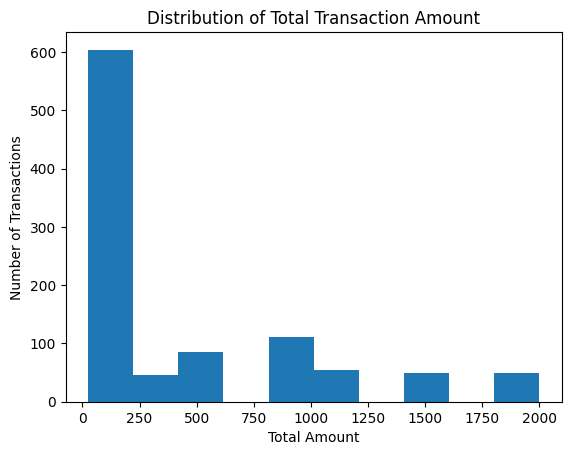

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.hist(df["Total Amount"], bins=10)

ax.set_title("Distribution of Total Transaction Amount")
ax.set_xlabel("Total Amount")
ax.set_ylabel("Number of Transactions")
plt.savefig("figures/Distribution of Total Amount.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()

### Interpretation

The histogram shows that most transactions have relatively low total amounts, with the largest concentration occurring below approximately 250.

The number of transactions decreases as the total amount increases, although several smaller groups of transactions appear around 500, 1,000, 1,500, and 2,000.

This indicates that the distribution of `Total Amount` is not uniform. Most transactions are concentrated at lower amounts, while higher-value transactions occur less frequently.

## 21. Visualization — Total Amount by Product Category

Which product category generates the highest total sales amount?

A bar chart is appropriate because we want to compare a numerical value (`Total Amount`) across discrete categories (`Product Category`). We will first calculate the total amount for each category and then visualize the comparison.

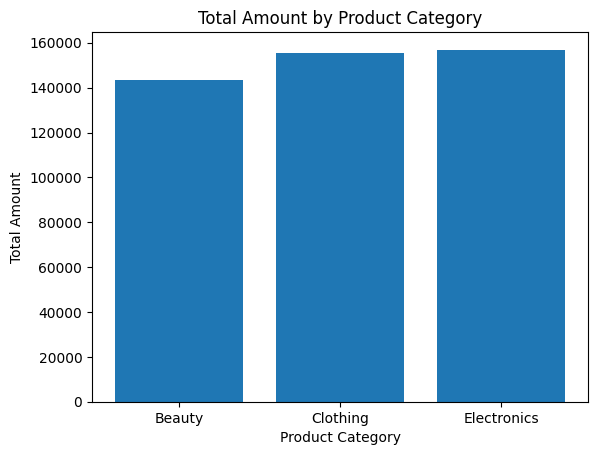

In [22]:
category_totals = df.groupby("Product Category")["Total Amount"].sum()

fig, ax = plt.subplots()

ax.bar(category_totals.index, category_totals.values)

ax.set_title("Total Amount by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Amount")

plt.savefig("figures/02_total_amount_by_category.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The bar chart shows that Electronics generates the highest total sales amount, followed closely by Clothing. Beauty has the lowest total sales amount among the three categories.

The total sales amounts are relatively close across all categories, indicating that no single product category dominates the overall sales. Electronics performs slightly better than Clothing and Beauty.

## 22. Visualization — Average Total Amount by Gender

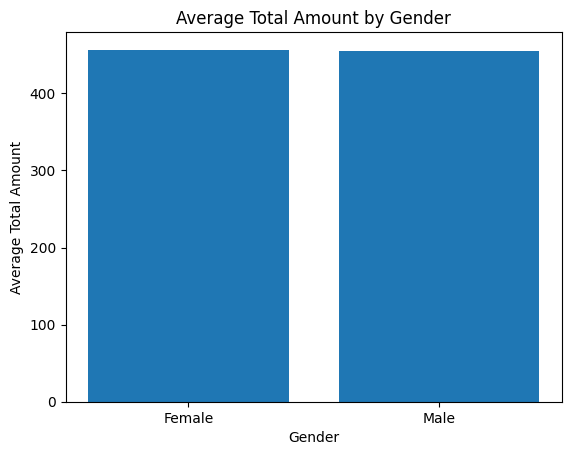

In [23]:
gender_avg = df.groupby("Gender")["Total Amount"].mean()

fig, ax = plt.subplots()

ax.bar(gender_avg.index, gender_avg.values)

ax.set_title("Average Total Amount by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Average Total Amount")

plt.savefig("figures/03_avg_amount_by_gender.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The bar chart shows that the average total transaction amount is almost the same for both Female and Male customers.

There is only a very small difference between the two groups, indicating that gender does not have a significant impact on the average transaction amount in this dataset.

## 23. Visualization — Age vs Total Amount

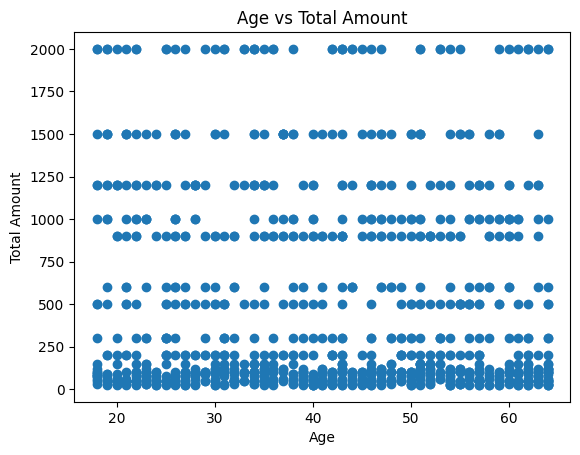

In [24]:
fig, ax = plt.subplots()

ax.scatter(df["Age"], df["Total Amount"])

ax.set_title("Age vs Total Amount")

ax.set_xlabel("Age")

ax.set_ylabel("Total Amount")

plt.savefig("figures/04_age_vs_total_amount.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The scatter plot shows no clear relationship between customer age and total transaction amount.

Transaction amounts are spread across different age groups, suggesting that customers of different ages make both lower-value and higher-value purchases.

The horizontal patterns indicate that transaction amounts occur at certain fixed price levels in the dataset.

Overall, age does not appear to be a strong factor in determining the total transaction amount. Therefore, other factors such as product category or customer purchasing behavior may be more useful for understanding spending patterns.

## 24. Visualization — Monthly Sales Trend

In [25]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

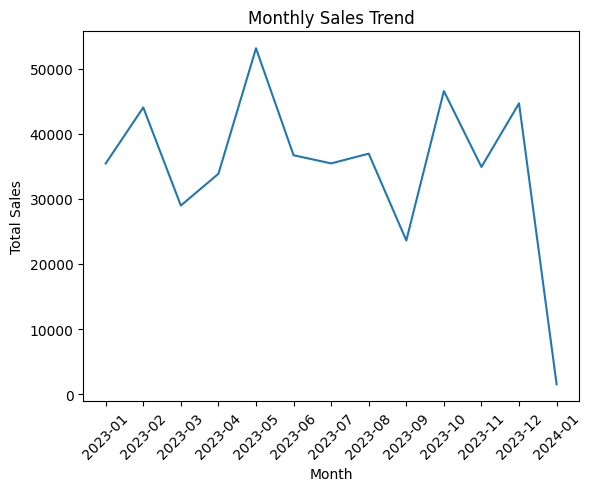

In [26]:
fig, ax = plt.subplots()

ax.plot(monthly_sales.index.astype(str), monthly_sales.values)

ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales")

plt.xticks(rotation=45)

plt.savefig("figures/05_monthly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The line chart shows considerable variation in total sales across different months.

May 2023 recorded the highest total sales, while September 2023 showed a noticeable decline. Sales increased again in October and December 2023.

January 2024 shows a very low sales value compared with previous months, which may indicate that the data for this month is incomplete.

Overall, the monthly sales trend is fluctuating rather than following a consistent upward or downward pattern.

## 25. Visualization — Sales by Product Category

In [27]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()

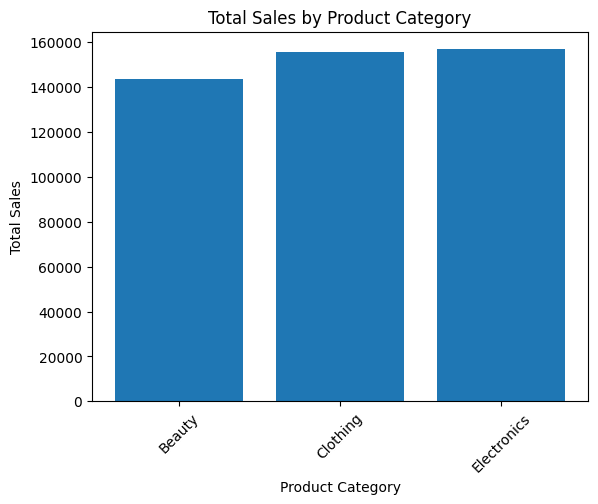

In [28]:
fig, ax = plt.subplots()

ax.bar(category_sales.index, category_sales.values)

ax.set_title("Total Sales by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Sales")

plt.xticks(rotation=45)

plt.savefig("figures/06_total_sales_by_category.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The bar chart shows that Electronics has the highest total sales, followed closely by Clothing.

Beauty has the lowest total sales among the three categories, although the difference is relatively small.

Overall, sales are fairly evenly distributed across the three product categories, indicating that the business is not heavily dependent on a single category.

Beauty could provide an opportunity for growth through promotions, product bundles, or targeted marketing strategies.

## 26. Visualization — Total Sales by Gender

In [29]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()

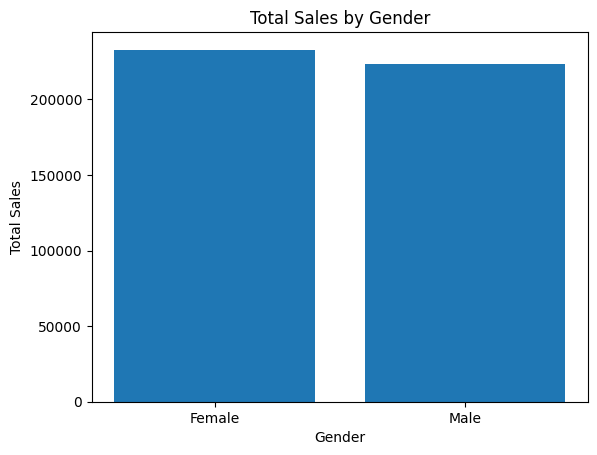

In [30]:
fig, ax = plt.subplots()

ax.bar(gender_sales.index, gender_sales.values)

ax.set_title("Total Sales by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Total Sales")

plt.savefig("figures/07_total_sales_by_gender.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The bar chart shows that Female customers contribute slightly higher total sales than Male customers.

However, the difference between the two groups is relatively small, indicating that total sales are fairly balanced across genders.

This suggests that the business is not strongly dependent on one gender segment. A broad, gender-neutral marketing strategy may therefore be appropriate for this dataset.

## 27. Visualization — Sales by Age Group

In [31]:
## Create Age Groups
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

In [32]:
age_group_sales = df.groupby("Age Group", observed=True)["Total Amount"].sum()

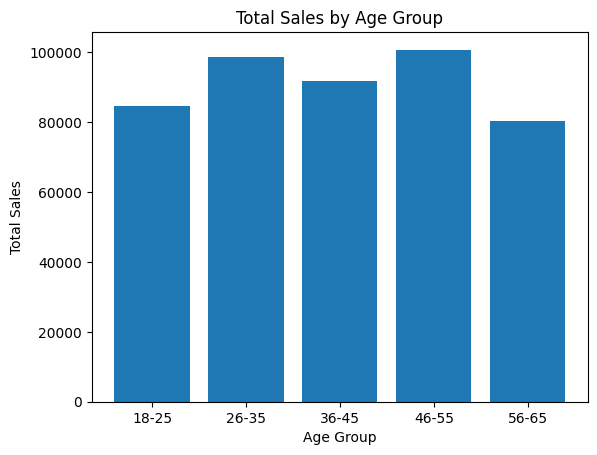

In [33]:
fig, ax = plt.subplots()

ax.bar(age_group_sales.index, age_group_sales.values)

ax.set_title("Total Sales by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Total Sales")

plt.savefig("figures/08_total_sales_by_age_group.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The bar chart shows that the 46-55 age group generates the highest total sales, followed closely by the 26-35 age group.

The 36-45 age group also contributes substantially to total sales, while the 18-25 and 56-65 age groups have comparatively lower sales.

Overall, middle-aged customer groups contribute more to total sales in this dataset. However, the lower sales from younger and older groups may also represent opportunities for targeted marketing and suitable product offerings.

## 28. Visualization — Correlation Heatmap

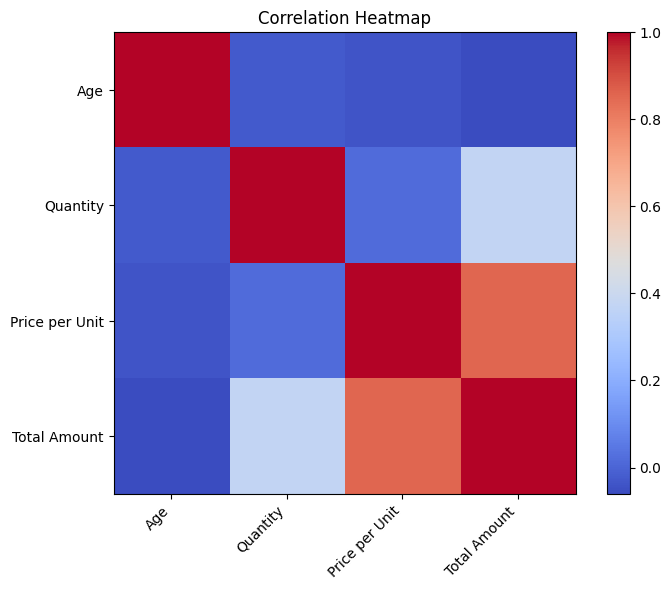

In [34]:
numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(correlation, cmap="coolwarm")

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))

ax.set_xticklabels(correlation.columns, rotation=45, ha="right")
ax.set_yticklabels(correlation.columns)

ax.set_title("Correlation Heatmap")

plt.colorbar(im)

plt.savefig("figures/12_correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The correlation heatmap shows that Price per Unit has the strongest positive correlation with Total Amount, indicating that higher-priced products are generally associated with higher transaction amounts.

Quantity has a weaker positive correlation with Total Amount, suggesting that transaction quantity also contributes to the total amount, but its relationship is less strong.

Age shows very weak correlation with the other numerical variables, indicating that age does not have a strong linear relationship with transaction amount, quantity, or unit price in this dataset.

There is also little correlation between Quantity and Price per Unit, suggesting that purchasing quantity and product price do not have a strong linear relationship.

Overall, Price per Unit appears to be the strongest numerical variable associated with Total Amount in this dataset.

## 29. Visualization — Transaction Amount Distribution by Gender

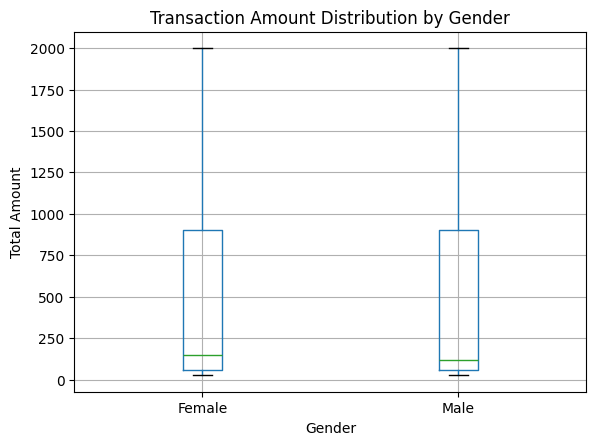

In [35]:
fig, ax = plt.subplots()

df.boxplot(
    column="Total Amount",
    by="Gender",
    ax=ax
)

ax.set_title("Transaction Amount Distribution by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Total Amount")

plt.suptitle("")

plt.savefig("figures/13_amount_distribution_gender.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The box plot shows that the distribution of transaction amounts is very similar for Female and Male customers.

Both groups have similar median transaction values and comparable overall spread, indicating that transaction amounts do not differ substantially by gender.

The distributions also show a wide range of transaction amounts, with values extending from lower transactions to higher-value purchases.

Overall, gender does not appear to create a major difference in transaction amount distribution in this dataset. Therefore, similar pricing and upselling strategies could be considered for both gender groups.

## 30. Visualization — Distribution of Quantity
How are product quantities distributed across transactions?

Histogram is appropriate because Quantity is a numerical variable and we want to understand its distribution.

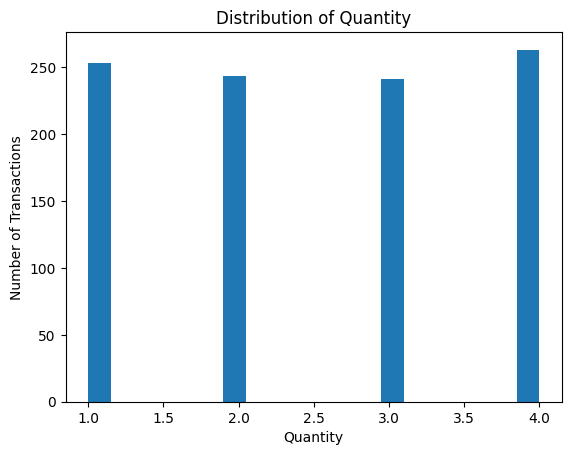

In [36]:
fig, ax = plt.subplots()

ax.hist(df["Quantity"], bins=20)

ax.set_title("Distribution of Quantity")
ax.set_xlabel("Quantity")
ax.set_ylabel("Number of Transactions")

plt.savefig("figures/14_quantity_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The histogram shows that transaction quantities are concentrated between 1 and 4 units.

The frequencies of the different quantity values are relatively similar, indicating that there is no strong preference for a particular quantity in this dataset.

Customers purchase both single-unit and multi-unit orders with comparable frequency.

Overall, the quantity distribution is fairly balanced across the observed values, although additional analysis would be needed to determine whether bundle offers could increase the quantity purchased.

## 31. Visualization — Distribution of Unit Price
How are product unit prices distributed across transactions?

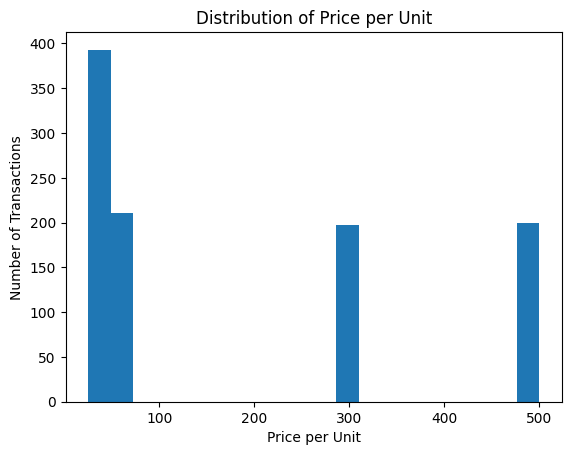

In [37]:
fig, ax = plt.subplots()

ax.hist(df["Price per Unit"], bins=20)

ax.set_title("Distribution of Price per Unit")
ax.set_xlabel("Price per Unit")
ax.set_ylabel("Number of Transactions")

plt.savefig("figures/15_price_per_unit_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

The histogram shows that Price per Unit is concentrated around several distinct price levels rather than being continuously distributed.

Most transactions occur at lower price levels, while additional groups of transactions appear around higher price points.

This indicates that the dataset contains different product price tiers, including lower-priced and higher-priced products.

Overall, the distribution suggests that customers purchase products across different price ranges, with lower-priced products appearing more frequently in the transactions.

## 32. EDA Summary & Key Findings

### Key Findings

- Total transaction amounts show considerable variation across the dataset.
- Female and Male customers have very similar average transaction amounts and overall spending patterns.
- Age does not show a clear relationship with Total Amount.
- Monthly sales fluctuate considerably, with some months showing noticeably higher or lower sales.
- Electronics has the highest total sales among the product categories, followed closely by Clothing.
- Sales are fairly distributed across the three product categories.
- The 46-55 and 26-35 age groups contribute the highest total sales.
- Price per Unit has the strongest positive correlation with Total Amount among the numerical variables.
- Quantity has a weaker positive relationship with Total Amount.
- Quantity values are concentrated between 1 and 4 units.
- Price per Unit shows several distinct pricing levels, with lower-priced products occurring more frequently.

### Overall Conclusion

The EDA shows that product price, product category, age group, and transaction quantity provide useful insights into customer purchasing behavior. However, gender and age do not show a strong direct relationship with transaction amount. Monthly sales also fluctuate over time, suggesting that further analysis could help identify the factors responsible for these variations.